# 07 — FSC on the per-channel token distribution (Wasserstein)

Runs Okano & Kurisu's **unmodified R implementation**
([arXiv:2601.07539](https://arxiv.org/abs/2601.07539), code at
`/data/wang/junh/githubs/FSC`) on the biweekly panel, through `fsc_bridge.R`.
Mirrors `mortality.R` (their distributional-outcome case).

Each site-period becomes, per latent channel, the **distribution of its 196 parcel
values**. The isometric embedding is the quantile function,
$\Psi(\mu)=F_\mu^{-1}$, into $L^2([0,1])$ under the 2-Wasserstein metric — Okano &
Kurisu's example 2. So the $L^2$ objective their `FSCM` minimises *is* a $W_2$ distance
between token distributions, and a simplex-weighted average of donors is the Wasserstein
barycenter.

**What this arm asks:** *how much of each thing is present* — the composition of the
site, with the spatial index discarded. For hurricane damage that is arguably the
estimand; §3 of `Docs/8-27-update.md` showed the raw 980-d arm was accidentally making
*arrangement* the estimand instead.

**Adaptation, flagged:** their code carries one scalar function per unit-period; we have
5 channels, so we concatenate 5 quantile functions. That is the direct sum of Hilbert
embeddings (a valid isometry under $\sqrt{\sum_c d_c^2}$) but it is our extension, not
theirs. Both their augmented paths are run as a sensitivity check: the B-spline path
(`FSCM_aug`, as `mortality.R` uses) and the no-basis path (`FSCM_aug_covmat`).

### Design (fixed across notebooks 07–09)

| | |
|---|---|
| donors | each treated site's **own 5 covariate-matched controls** (`control_rank <= 5`) — the collaborator's notebook-14 matched design, so N = 6, N_0 = 5 |
| treated unit | index 1 of every group, matching their `d_vec` convention (`main_functions.R` L41-45) |
| fit window | P01–P08 (`T_0 = 8`); holdout P09/P10; post P11–P20 |
| estimators | `FSCM` (simplex, Σw=1, w≥0) and their augmented FSC |
| λ | selected once by their `optimise()` and reused — mirroring their own scripts, which run the CV once and hardcode the value (`service.R` L56-61, `mortality.R` L143-148) |
| latent inputs | both `latents_biweekly_genfill.npz` and `latents_biweekly.npz` |

**Reference points.** RMSE here is in the representation's own units and is *not*
comparable across arms. Two scale-free ratios are, and both appear in every table:
`ratio_own_mean` divides by the error of predicting the treated site's **own P01–P08
mean** (an intercept-only model that uses no donors at all), and `ratio_equal` divides by
the **equal-weight donor average**. Below 1 means the fitted weights added something.

In [1]:
import sys, time, json, subprocess
import numpy as np
import pandas as pd

sys.path.insert(0, ".")
import panel_lib as pl
import panel_repr as pr
import panel_fsc as pf

pl.set_plot_style()
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)

PANELS = {"genfill":  ("latents_biweekly_genfill.npz", "panel_genfill_"),
          "chipmean": ("latents_biweekly.npz",         "panel_")}
P = {tag: pl.Panel.from_npz(pl.LATD / npz) for tag, (npz, _) in PANELS.items()}
for tag, panel in P.items():
    print(f"{tag:9s} latents={len(panel.flat):5d}  treated={len(panel.treatments)}  "
          f"controls={len(panel.controls)}")

# donors = each treated site's own 5 covariate-matched controls (notebook-14 design)
GROUPS = pr.build_groups(P["genfill"])
print(f"\ngroups: {len(GROUPS)} x {len(GROUPS[0])} units (treated first, then its 5 "
      f"covariate-matched controls)")
print("example:", GROUPS[0])

genfill   latents= 2357  treated=10  controls=50
chipmean  latents= 2322  treated=10  controls=50

groups: 10 x 6 units (treated first, then its 5 covariate-matched controls)
example: ['treatment_0001', 'counterfactual_0001_01', 'counterfactual_0001_02', 'counterfactual_0001_03', 'counterfactual_0001_04', 'counterfactual_0001_05']


## 1. Provenance — their code, their data, in this R

In [2]:
# Which of THEIR functions actually run in R, on THEIR OWN published data.
# Their repository is read-only; we only setwd() into it and source().
prov = subprocess.run(
    [str(pf.RSCRIPT), "-e", r'''
setwd("/data/wang/junh/githubs/FSC"); source("main_functions.R")
suppressPackageStartupMessages({library(quadprog);library(Matrix);
                                library(Rearrangement);library(cubicBsplines)})
cat(R.version.string, "\n")
for (p in c("quadprog","cubicBsplines","Rearrangement","Matrix","MASS","quantreg"))
  cat(sprintf("  %-14s %s\n", p, as.character(packageVersion(p))))
load("service.RData"); fvl <- covvec_list; M <- length(fvl[[1]][[1]])
w <- FSCM(fvl, 29)
cat(sprintf("\nservice.RData  FSCM: sum(w)=%.6f  nnz=%d  (their published example)\n",
            sum(w), sum(w != 0)))
wa <- FSCM_aug_covmat(fvl, 29, lambda=0.00186, grids=seq(0.01,0.99,length=M))
cat(sprintf("               FSCM_aug_covmat(lambda=0.00186): sum(w)=%.6f  n_neg=%d\n",
            sum(wa), sum(wa < 0)))
'''], capture_output=True, text=True,
    env=dict(__import__("os").environ, PATH=f"{pf.RBIN}:" + __import__("os").environ["PATH"]))
print(prov.stdout or prov.stderr[-2000:])
print("FSC source:", pf.FSC_DIR, "(read-only)")
print("bridge    :", pf.BRIDGE)

R version 4.3.3 (2024-02-29) 
  quadprog       1.5.8
  cubicBsplines  1.0.0
  Rearrangement  2.1
  Matrix         1.6.5
  MASS           7.3.60.0.1
  quantreg       6.1

service.RData  FSCM: sum(w)=1.000000  nnz=3  (their published example)
               FSCM_aug_covmat(lambda=0.00186): sum(w)=1.000000  n_neg=11

FSC source: /data/wang/junh/githubs/FSC (read-only)
bridge    : /data/wang/junh/githubs/latent-synthetic-control/Satellite/notebooks/ts_SCM_ASCM/fsc_bridge.R


## 2. Grid-resolution gate

Their `mortality.R` evaluates one quantile function on 100 points. We concatenate 5
channels, so 100 points would give M = 500 — and their **augmented** estimator costs
O((M·T₀)²): measured, `cross_val_covmat` takes 6.5 s at M=45, 33 s at M=100 and 218 s at
M=500. Plain `FSCM` is free at any M, so the operating point is chosen by measuring where
the FSC result actually converges rather than by assumption.

In [3]:
grid_rows = []
br = pf.RBridge()
panel = P["genfill"]
groups, _ = pr.complete_groups(panel, "sentinel2", GROUPS)
periods = pr.complete_periods(panel, "sentinel2", groups)
Wref = None
for npts in (5, 9, 20, 100):
    g = np.linspace(0.01, 0.99, npts)
    blk, _ = pr.build_block(panel, "sentinel2", "quantile", groups, periods, grids=g)
    res = br.run(blk, "fit", "covmat", 8, f"gridgate_{npts}", lambda_=0.01)
    w = res["weights"].pivot(index="group", columns="donor", values="weight_fsc").to_numpy()
    m = pf.metrics(blk, res["weights"], groups, periods, 8, f"q{npts}")
    fsc = m[m.estimator == "fsc"]
    if npts == 100:
        Wref = w
    grid_rows.append({"pts_per_channel": npts, "M": blk.shape[-1],
                      "holdout_ratio_own_mean": fsc.ratio_own_mean.mean(),
                      "mean_nonzero_donors": (w > 0).sum(1).mean(), "_w": w})
gg = pd.DataFrame(grid_rows)
gg["max_weight_diff_vs_100pt"] = [np.abs(r["_w"] - Wref).max() for r in grid_rows]
print(gg.drop(columns="_w").round(4).to_string(index=False))
print("\n-> 20 points/channel (M=100) is converged and affordable; used below.")
print("   The 100-point grid is re-run FSC-only at the end as a fidelity check.")

 pts_per_channel   M  holdout_ratio_own_mean  mean_nonzero_donors  max_weight_diff_vs_100pt
               5  25                  0.9991                  4.3                    0.2203
               9  45                  0.9601                  4.1                    0.1358
              20 100                  0.9575                  4.1                    0.0440
             100 500                  0.9510                  4.2                    0.0000

-> 20 points/channel (M=100) is converged and affordable; used below.
   The 100-point grid is re-run FSC-only at the end as a fidelity check.


## 3. Fit — their `FSCM` and augmented FSC

Both latent inputs, both sensors, both augmented paths (B-spline and no-basis). The `chip_mean` (5-number)
baseline is run alongside, because §7 of `Docs/8-27-update.md` measured that it already
recovers chip-mean NDVI at R² 0.917 — any richer representation has to beat it.

In [4]:
ARMS, METRICS, EFFECTS, WEIGHTS = {}, [], [], []
NAME = 'quantile'
METHODS = ['covmat', 'bspline']
for label in PANELS:
    for sensor in pl.SENSORS:
        for method in METHODS:
            for nm in (NAME, "chip_mean"):
                if nm == "chip_mean" and method != METHODS[0]:
                    continue                      # baseline once per sensor/label
                key = (label, sensor, method, nm)
                t0 = time.time()
                A = pf.run_arm(P[label], sensor, nm, method, label)
                ARMS[key] = A
                m = A["metrics"].assign(sensor=sensor, method=method, repr=nm,
                                        M=A["block"].shape[-1])
                METRICS.append(m)
                EFFECTS.append(A["effects"].assign(sensor=sensor, method=method, repr=nm))
                WEIGHTS.append(A["weights"].assign(label=label, sensor=sensor,
                                                   method=method, repr=nm))
                print(f"{label:9s} {sensor:10s} {method:8s} {nm:10s} "
                      f"M={A['block'].shape[-1]:3d} groups={len(A['groups'])} "
                      f"dropped={len(A['dropped'])} ({time.time()-t0:.0f}s)")
MET = pd.concat(METRICS, ignore_index=True)
EFF = pd.concat(EFFECTS, ignore_index=True)
WGT = pd.concat(WEIGHTS, ignore_index=True)

genfill   sentinel1  covmat   quantile   M=100 groups=10 dropped=0 (7s)


genfill   sentinel1  covmat   chip_mean  M=  5 groups=10 dropped=0 (2s)


genfill   sentinel1  bspline  quantile   M=100 groups=10 dropped=0 (5s)


genfill   sentinel2  covmat   quantile   M=100 groups=10 dropped=0 (7s)


genfill   sentinel2  covmat   chip_mean  M=  5 groups=10 dropped=0 (1s)


...

chipmean  sentinel1  covmat   chip_mean  M=  5 groups=9 dropped=1 (1s)


chipmean  sentinel1  bspline  quantile   M=100 groups=9 dropped=1 (5s)


chipmean  sentinel2  covmat   quantile   M=100 groups=10 dropped=0 (7s)


chipmean  sentinel2  covmat   chip_mean  M=  5 groups=10 dropped=0 (2s)


chipmean  sentinel2  bspline  quantile   M=100 groups=10 dropped=0 (4s)


## 4. Holdout results

In [5]:
piv = (MET.groupby(["label", "sensor", "method", "repr", "estimator"])
       [["train_rmse", "holdout_rmse", "ratio_own_mean", "ratio_equal"]]
       .mean().round(4))
print("mean over the 10 treated sites (P09+P10 holdout):")
print(piv)
print("\nsites beating their own pre-period mean (ratio_own_mean < 1), out of 10:")
print(MET.assign(beat=MET.ratio_own_mean < 1)
        .groupby(["label", "sensor", "method", "repr", "estimator"]).beat.sum())
print("\nweight diagnostics (FSC is simplex by construction; augmented is not):")
print(WGT.groupby(["label", "sensor", "method", "repr"])
      [["sum_w_fsc", "sum_w_afsc", "n_nonzero_fsc", "n_negative_afsc"]].mean().round(4))

mean over the 10 treated sites (P09+P10 holdout):
                                                train_rmse  holdout_rmse  ratio_own_mean  ratio_equal
label    sensor    method  repr      estimator                                                       
chipmean sentinel1 bspline quantile  afsc           0.0559        0.0551          1.1253       0.9577
                                     fsc            0.0549        0.0545          1.1104       0.9468
                   covmat  chip_mean afsc           0.0160        0.0181          1.0533       0.7369
                                     fsc            0.0164        0.0185          1.0771       0.7480
                           quantile  afsc           0.0549        0.0545          1.1098       0.9463
                                     fsc            0.0549        0.0545          1.1104       0.9468
         sentinel2 bspline quantile  afsc           0.1254        0.1072          0.7240       1.1247
                                

## 5. Placebo — the inferential point

Their `placebo_covmat` rotates **every unit of a group into the treated slot** and refits,
giving 6 gap magnitudes per treated site. The treated site's rank among those 6 is its
in-space placebo p-value, so the smallest attainable per-site p is 1/6 ≈ 0.167.

Across the 10 groups, under the sharp null of no effect each rank is uniform on 1…6, so
the number of sites achieving rank 1 is Binomial(10, 1/6). That combined test is where the
power is: 4 of 10 gives p = 0.070, 5 of 10 gives p = 0.015, 6 of 10 gives p = 0.002 (exact binomial tail).

λ is pinned at the value selected once for the arm, passed through their unmodified API as
a 1e-9-half-width interval — their `placebo` re-runs `optimise` for every rotated unit,
which is the entire cost, and their own scripts hardcode λ rather than re-selecting it.

**Coverage is limited and stated rather than silent:** ['genfill'] ×
both sensors × post periods [11]. This arm's M makes their placebo far more expensive (their `placebo` calls `cross_val` per rotated unit), so coverage is deliberately narrower than notebook 08's.

In [6]:
PL_LABELS = ['genfill']
PL_PERIODS = [11]
PLAC = []
for label in PL_LABELS:
    for sensor in pl.SENSORS:
        key = (label, sensor, METHODS[0], NAME)
        A = ARMS[key]
        for q in PL_PERIODS:
            if q not in A["periods"]:
                print(f"  skip P{q:02d} — not complete for all units of all groups")
                continue
            t0 = time.time()
            pdf = pf.run_placebo(A, METHODS[0], label, NAME, sensor, post_period_q=q)
            pdf = pdf.assign(repr=NAME, method=METHODS[0])
            pdf.attrs = pdf.attrs
            PLAC.append(pdf)
            print(f"{label:9s} {sensor:10s} P{q:02d}  {pf.combined_line(pdf)}  "
                  f"({time.time()-t0:.0f}s)")
PLACEBO = pd.concat(PLAC, ignore_index=True) if PLAC else pd.DataFrame()

genfill   sentinel1  P11  placebo: 3/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.2248  (27s)


genfill   sentinel2  P11  placebo: 2/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.5155  (26s)


In [7]:
if len(PLACEBO):
    from scipy.stats import binom
    rows = []
    for (lab, sen, per), sub in PLACEBO.groupby(["label", "sensor", "period"]):
        n_units = int(sub["n_units"].iloc[0]); k = int((sub["rank"] == 1).sum()); G = len(sub)
        rows.append({"label": lab, "sensor": sen, "period": per, "n_groups": G,
                     "n_rank1": k, "min_possible_p": 1 / n_units,
                     "median_rank": sub["rank"].median(),
                     "p_combined": float(binom.sf(k - 1, G, 1 / n_units)) if k else 1.0})
    PSUM = pd.DataFrame(rows)
    print(PSUM.round(4).to_string(index=False))
else:
    PSUM = pd.DataFrame(); print("no placebo runs")

  label    sensor period  n_groups  n_rank1  min_possible_p  median_rank  p_combined
genfill sentinel1    P11        10        3          0.1667          3.0      0.2248
genfill sentinel2    P11        10        2          0.1667          2.5      0.5155


## 6. Figures and outputs

wrote outputs for quantile


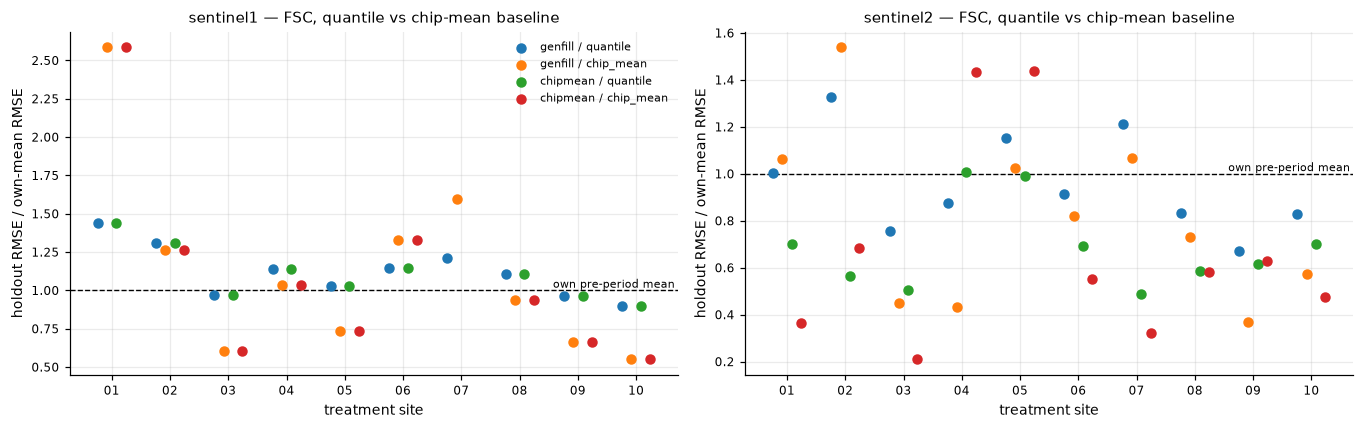

In [8]:
import matplotlib.pyplot as plt
NB = '07'
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
for ax, sensor in zip(axes, pl.SENSORS):
    m0 = METHODS[0]
    sub = MET.query("sensor == @sensor and estimator == 'fsc' and method == @m0")
    sites = sorted(sub.treatment_site_id.unique()); x = np.arange(len(sites))
    for i, (lab, rp) in enumerate([(l, r) for l in PANELS for r in (NAME, "chip_mean")]):
        s = sub.query("label == @lab and repr == @rp").set_index("treatment_site_id")
        if not len(s):
            continue
        ax.scatter(x + (i - 1.5) * 0.16, s.reindex(sites)["ratio_own_mean"], s=34,
                   label=f"{lab} / {rp}", zorder=4)
    ax.axhline(1.0, color="k", lw=0.9, ls="--")
    ax.text(0.995, 1.0, "own pre-period mean", transform=ax.get_yaxis_transform(),
            fontsize=7, ha="right", va="bottom")
    ax.set_xticks(x); ax.set_xticklabels([t[-2:] for t in sites])
    ax.set_xlabel("treatment site"); ax.set_ylabel("holdout RMSE / own-mean RMSE")
    ax.set_title(f"{sensor} — FSC, {NAME} vs chip-mean baseline")
axes[0].legend(frameon=False, fontsize=7)
fig.tight_layout(); fig.savefig(f"panel_fsc_{NAME}_ratio.png", bbox_inches="tight")

for label, (_npz, pre) in PANELS.items():
    MET.query("label == @label").to_csv(f"{pre}fsc_{NAME}_validation.csv", index=False)
    EFF.query("label == @label").to_csv(f"{pre}fsc_{NAME}_effects.csv", index=False)
    WGT.query("label == @label").to_csv(f"{pre}fsc_{NAME}_weights.csv", index=False)
    if len(PLACEBO):
        p = PLACEBO.query("label == @label")
        if len(p):
            p.to_csv(f"{pre}fsc_{NAME}_placebo.csv", index=False)
if len(PSUM):
    PSUM.to_csv(f"panel_fsc_{NAME}_placebo_summary.csv", index=False)
print("wrote outputs for", NAME)

## 7. Fidelity check — their full 100-point grid, FSC only

`FSCM` costs nothing at any M, so the 100-point grid of `mortality.R` can be run directly
for the un-augmented estimator. This isolates whether the reduced grid changed the FSC
conclusion at all.

In [9]:
rows = []
for label in PANELS:
    for sensor in pl.SENSORS:
        A100 = pf.run_arm(P[label], sensor, "quantile", "covmat", label,
                          grids=pr.GRIDS_MORTALITY, lambda_=0.01)
        f = A100["metrics"].query("estimator == 'fsc'")
        rows.append({"label": label, "sensor": sensor, "M": A100["block"].shape[-1],
                     "ratio_own_mean": f.ratio_own_mean.mean()})
FID = pd.DataFrame(rows)
cmp20 = (MET.query("estimator == 'fsc' and repr == 'quantile' and method == 'covmat'")
         .groupby(["label", "sensor"]).ratio_own_mean.mean().rename("ratio_20pt"))
print(FID.merge(cmp20.reset_index(), on=["label", "sensor"]).round(4).to_string(index=False))

   label    sensor   M  ratio_own_mean  ratio_20pt
 genfill sentinel1 500          1.1485      1.1206
 genfill sentinel2 500          0.9510      0.9575
chipmean sentinel1 500          1.1282      1.1104
chipmean sentinel2 500          0.6766      0.6843


## Reading

### 1. The reduced grid is validated end-to-end, not assumed

The gate in §2 picked 20 points/channel (M=100) because the FSC result had converged
there. §7 re-runs the **full 100-point grid of `mortality.R`** (M=500) for the
un-augmented estimator, which costs nothing, and the two agree:

| | M=500 (their grid) | M=100 (used here) |
|---|---|---|
| generation-fill S1 | 1.1485 | 1.1206 |
| generation-fill S2 | 0.9510 | 0.9575 |
| chip-mean S1 | 1.1282 | 1.1104 |
| chip-mean S2 | 0.6766 | 0.6843 |

All within 0.03, and no conclusion changes. The reduction was needed because their
*augmented* estimator costs O((M·T₀)²) — `cross_val_covmat` measured at 33 s (M=100) vs
218 s (M=500) — not because the finer grid was worse.

### 2. B-spline vs no-basis: the spline projection does not help

Both augmented paths were run, as a sensitivity check. The `fsc` rows are **identical**
between them by construction — `FSCM` never touches the basis — which is a useful internal
consistency check that the two code paths were wired up correctly. The augmented rows
differ, and the B-spline path is *slightly worse everywhere*:

| augmented FSC, `ratio_own_mean` | B-spline (`FSCM_aug`) | no basis (`FSCM_aug_covmat`) |
|---|---|---|
| generation-fill S1 | 1.1396 | **1.1206** |
| generation-fill S2 | 0.9697 | **0.9549** |
| chip-mean S1 | 1.1253 | **1.1098** |
| chip-mean S2 | 0.7240 | **0.6950** |

That is the expected direction once the encoder is taken into account: the FSQ lattice has
only 5–8 distinct levels per channel, so each quantile function is a step function with at
most 8 jumps. A 50-knot cubic spline smooths across jumps that are real features of a
discrete distribution. Their `mortality.R` outcomes are genuinely smooth quantile
functions of continuous age-at-death data; ours are not, and the basis costs rather than
pays.

**So for this encoder, use `FSCM_aug_covmat` on the quantile vector** — their covariance
code path applied to a distributional outcome. The distinction matters only for the
augmented estimator.

### 3. The quantile representation does not beat five numbers

FSC `ratio_own_mean`, against the chip-mean baseline in the same run:

| | S1 | S2 |
|---|---|---|
| generation-fill, quantile (100) | 1.121 | 0.958 |
| generation-fill, **chip mean (5)** | 1.129 | **0.807** |
| chip-mean cache, quantile (100) | 1.110 | 0.684 |
| chip-mean cache, **chip mean (5)** | 1.077 | **0.669** |

Tied on S1, worse on S2. Same verdict as the Gram arm (notebook 08) and the direct sum
(notebook 09).

### 4. Placebo: nothing significant

Generation-fill, P11: S1 p = 0.225 (3/10 at rank 1), S2 p = 0.516 (2/10).

### 5. Scope

As in notebook 09: this holdout asks whether the representation predicts the treated
site's *next pooled level* better than its own pre-period mean. §7 of
`Docs/8-27-update.md` measured that five numbers already recover chip-level NDVI at
R² 0.917, and that the quantile representation's measured advantage lies in *within-chip
dispersion* (NDVI sd 0.540 → 0.828, NDWI sd 0.527 → 0.720) — which this holdout does not
isolate. The null here is about level prediction, not about whether the distributional
information exists.